## MỞ ĐẦU

# Phân tích rủi ro danh mục BTC – Vàng – S&P 500, giai đoạn 2023–2024

Bài tiểu luận nghiên cứu danh mục gồm Bitcoin (BTC/USD), vàng giao ngay
(XAU/USD) và chỉ số S&P 500, đại diện cho thị trường cổ phiếu. Dữ liệu giá
từ Investing.com được giới hạn từ **01/01/2023 đến 31/12/2024**. Ba nhiệm vụ
chính là phân tích tương quan, tính kỳ vọng và rủi ro danh mục bằng tổ hợp
tuyến tính, sau đó ước lượng VaR và ES 95% bằng Monte Carlo.

Nhóm sử dụng trọng số cơ sở **20% BTC – 30% Vàng – 50% S&P 500**, vốn giả
định **100.000 USD**, kỳ hạn **một phiên chung**, **100.000 mô phỏng/phương
pháp**, seed **42**. Hai danh mục bổ sung dùng để so sánh trọng số.
Trọng số mục tiêu được giữ qua các phiên; không xét thuế, phí, trượt giá
hoặc cổ tức. Chỉ số S&P 500 và vàng giao ngay đóng vai trò đại diện giá,
không phải mô hình thực thi giao dịch ETF.

Theo đề bài, $r_p\approx\sum_i w_i r_i$ là **xấp xỉ log return danh mục**.
Log return chính xác của danh mục một phiên sẽ là
$\ln(\sum_i w_i e^{r_i})$. Các kết quả dưới đây nhất quán với mô hình
xấp xỉ đã chọn; lợi nhuận kỳ vọng log không phải lợi nhuận đơn dự báo.
Quy đổi năm dùng 252 phiên và giả định return độc lập theo thời gian,
tham số ổn định. Một phiên chung có thể bao gồm nhiều ngày lịch.

Cell sau khởi tạo môi trường và các tham số dùng xuyên suốt bài.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import json
import hashlib
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'script' / 'preprocessing.py').is_file()
             and (p / 'data').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Mở notebook bên trong thư mục dự án có data và script.')
sys.path.insert(0, str(ROOT / 'script'))
from preprocessing import prepare, write_outputs, ASSETS, SOURCES

OUTPUT = ROOT / 'data' / 'processed'
DAYS = 252
CAPITAL = 100_000.0
CONFIDENCE = 0.95
N_SIM = 100_000
SEED = 42
LABELS = {'BTC': 'Bitcoin', 'GOLD': 'Vàng', 'SP500': 'S&P 500'}
BASE = 'Cơ sở 20/30/50'
weights = pd.DataFrame(
    [[0.2, 0.3, 0.5], [1/3, 1/3, 1/3], [0.1, 0.4, 0.5]],
    index=[BASE, 'Chia đều', '10/40/50'], columns=list(ASSETS))
w = weights.loc[BASE].to_numpy()
plt.rcParams.update({'figure.figsize': (9, 4.8), 'figure.dpi': 115,
                     'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.2})
pd.set_option('display.max_columns', 15)
pd.set_option('display.precision', 6)

def note(text):
    display(Markdown('**Nhận xét.** ' + text))

def table(frame, caption):
    display(Markdown('**' + caption + '**'))
    display(frame.round(6))

def pct(value):
    return f'{value:.3%}'

table(pd.DataFrame({'Giá trị': [CAPITAL, CONFIDENCE, N_SIM, SEED, DAYS]},
                   index=['Vốn (USD)', 'Mức tin cậy', 'Mô phỏng/phương pháp',
                          'Seed', 'Phiên/năm']), 'Tham số chung')

**Tham số chung**

,Giá trị
Vốn (USD),100000.00
Mức tin cậy,0.95
Mô phỏng/phương pháp,100000.00
Seed,42.00
Phiên/năm,252.00


## P1 – 1.1 Nguồn dữ liệu và khoảng thời gian

Ba CSV đã tải được giữ nguyên trong `data`. Dùng cột **Price**, không dùng
`Open` hoặc `Change %`. BTC có đơn vị USD/BTC, vàng USD/troy ounce,
S&P 500 là điểm chỉ số. Giá trị tuyệt đối không so sánh trực tiếp giữa tài
sản; phân tích tương quan sử dụng return không có đơn vị.

Nguồn: [BTC](https://www.investing.com/crypto/bitcoin/historical-data),
[XAU/USD](https://www.investing.com/currencies/xau-usd-historical-data),
[S&P 500](https://www.investing.com/indices/us-spx-500-historical-data).
Cell sau gọi script tiền xử lý để dữ liệu và báo cáo khớp các CSV hiện tại.

In [2]:
prices, report = prepare(ROOT / 'data')
write_outputs(prices, report, OUTPUT)
source_table = pd.DataFrame([
    {'Mã': a, 'Tài sản': s['name'], 'Nguồn': 'Investing.com',
     'Loại giá': 'Price (đóng cửa)', 'Đơn vị': s['unit'],
     'Số dòng CSV': s['raw_rows'], 'Quan sát 2023–2024': s['period_rows'],
     'Từ ngày': s['period_start'], 'Đến ngày': s['period_end']}
    for a, s in report['sources'].items()]).set_index('Mã')
table(source_table, 'Nguồn, loại giá và số quan sát trước đồng bộ')
note(f"BTC có {source_table.loc['BTC', 'Quan sát 2023–2024']} quan sát, "
     f"Vàng {source_table.loc['GOLD', 'Quan sát 2023–2024']} và S&P 500 "
     f"{source_table.loc['SP500', 'Quan sát 2023–2024']}. Số dòng khác nhau "
     'phản ánh lịch giao dịch, chưa đồng nghĩa với missing prices.')

**Nguồn, loại giá và số quan sát trước đồng bộ**

,Tài sản,Nguồn,Loại giá,Đơn vị,Số dòng CSV,Quan sát 2023–2024,Từ ngày,Đến ngày
Mã,,,,,,,,
BTC,Bitcoin (BTC/USD),Investing.com,Price (đóng cửa),USD/BTC,731,731,2023-01-01,2024-12-31
GOLD,Vàng giao ngay (XAU/USD),Investing.com,Price (đóng cửa),USD/troy ounce,519,519,2023-01-02,2024-12-31
SP500,S&P 500 (SPX),Investing.com,Price (đóng cửa),Điểm chỉ số,502,502,2023-01-03,2024-12-31


**Nhận xét.** BTC có 731 quan sát, Vàng 519 và S&P 500 502. Số dòng khác nhau phản ánh lịch giao dịch, chưa đồng nghĩa với missing prices.

## P1 – 1.2 Kiểm tra, đồng bộ và xử lý dữ liệu

Script parse ngày bằng định dạng riêng từng nguồn, loại dấu phẩy hàng
nghìn và kiểm tra giá dương, hữu hạn. Ngày/giá thiếu hoặc không hợp lệ và
ngày trùng khác giá gây lỗi; ngày trùng cùng giá được gộp và ghi nhận.
Missing ở `Vol.` không ảnh hưởng vì bài chỉ dùng `Date`, `Price`.

Lấy **giao ngày có giá của cả ba tài sản**, không điền giá hoặc nội suy.
BTC giao dịch cuối tuần nhưng các ngày không có giá chung bị loại.
Gắn cờ $|r_t|>10\%$ trên chuỗi đồng bộ, không tự động xóa hoặc winsorize.
Ngày trùng nhãn giữa các thị trường không bảo đảm cùng giờ đóng cửa.

In [3]:
qa_table = pd.DataFrame([
    {'Mã': a, 'Missing Date': s['missing_values_by_column']['Date'],
     'Missing Price': s['missing_values_by_column']['Price'],
     'Missing Vol.': s['missing_values_by_column'].get('Vol.', 0),
     'Trùng cùng giá đã gộp': s['identical_duplicate_rows_removed'],
     'Ngoài kỳ đã loại': s['outside_period_rows_removed'],
     'Ngày bị loại khi đồng bộ': s['alignment_rows_removed']}
    for a, s in report['sources'].items()]).set_index('Mã')
table(qa_table, 'Kiểm tra chất lượng và số ngày bị loại')
gaps = pd.DataFrame(list(report['alignment']['gap_days_histogram'].items()),
                    columns=['Khoảng cách (ngày lịch)', 'Số lần'])
table(gaps, 'Khoảng cách giữa hai phiên chung liên tiếp')
flag_table = pd.DataFrame(report['outlier_flags'])
table(flag_table, 'Biến động lớn được gắn cờ và giữ nguyên')
assert prices.index.is_unique and prices.index.is_monotonic_increasing
assert np.isfinite(prices.to_numpy()).all() and (prices > 0).all().all()
note(f"Còn **{len(prices)} ngày giá chung**, từ {prices.index.min():%d/%m/%Y} "
     f"đến {prices.index.max():%d/%m/%Y}; không còn missing prices. "
     f"Có {len(flag_table)} biến động vượt ngưỡng, được giữ lại. Khoảng cách "
     f"lớn nhất là {report['alignment']['max_gap_calendar_days']} ngày lịch.")

**Kiểm tra chất lượng và số ngày bị loại**

,Missing Date,Missing Price,Missing Vol.,Trùng cùng giá đã gộp,Ngoài kỳ đã loại,Ngày bị loại khi đồng bộ
Mã,,,,,,
BTC,0,0,0,0,0,229
GOLD,0,0,519,0,0,17
SP500,0,0,502,0,0,0


**Khoảng cách giữa hai phiên chung liên tiếp**

,Khoảng cách (ngày lịch),Số lần
0,1,391
1,2,6
2,3,91
3,4,13


**Biến động lớn được gắn cờ và giữ nguyên**

,asset,date,previous_common_date,log_return,action
0,BTC,2023-03-13,2023-03-10,0.179272,flag_only_keep_observation
1,BTC,2023-10-23,2023-10-20,0.107485,flag_only_keep_observation
2,BTC,2024-07-15,2024-07-12,0.112574,flag_only_keep_observation
3,BTC,2024-08-05,2024-08-02,-0.130096,flag_only_keep_observation
4,BTC,2024-08-08,2024-08-07,0.112750,flag_only_keep_observation
5,BTC,2024-11-11,2024-11-08,0.147338,flag_only_keep_observation


**Nhận xét.** Còn **502 ngày giá chung**, từ 03/01/2023 đến 31/12/2024; không còn missing prices. Có 6 biến động vượt ngưỡng, được giữ lại. Khoảng cách lớn nhất là 4 ngày lịch.

## P1 – 1.3 Tính tỉ suất sinh lợi

Với hai ngày **chung liên tiếp**, tính daily log return:

$$r_{i,t}=\ln(P_{i,t}/P_{i,t-1}).$$

Tính sau đồng bộ để BTC, vàng và S&P 500 có cùng khoảng đo return.
Return thứ Hai của BTC gồm biến động kể từ phiên chung trước đó, bao
gồm cuối tuần. Dòng giá đầu tiên không có giá trước trong mẫu nên bị
loại khi tính return. Không lấy thêm giá năm 2022.

Xuất `returns_2023_2024.csv` gồm `Date,BTC,GOLD,SP500`, đơn vị số thập phân,
để cả nhóm dùng chung. Mean và covariance phần sau được tính từ file này.

In [4]:
returns = np.log(prices / prices.shift(1)).dropna()
assert len(returns) == len(prices) - 1
assert np.isfinite(returns.to_numpy()).all()
returns.to_csv(OUTPUT / 'returns_2023_2024.csv', date_format='%Y-%m-%d')
mu = returns.mean()
sigma = returns.cov(ddof=1)
asset_vol = returns.std(ddof=1)
table(returns.head() * 100, 'Năm dòng đầu Return dataset (%)')
table(pd.DataFrame({'Số quan sát': returns.count(),
                    'Mean log return/ngày (%)': mu * 100,
                    'SD log return/ngày (%)': asset_vol * 100}),
      'Thống kê mô tả return')
long_gap_date = prices.index[prices.index.to_series().diff().dt.days.gt(1)][0]
prev_date = prices.index[prices.index.get_loc(long_gap_date) - 1]
expected_btc = np.log(prices.loc[long_gap_date, 'BTC'] / prices.loc[prev_date, 'BTC'])
np.testing.assert_allclose(returns.loc[long_gap_date, 'BTC'], expected_btc)
note(f"Return dataset có **{len(returns)} quan sát** từ "
     f"{returns.index.min():%d/%m/%Y} đến {returns.index.max():%d/%m/%Y}. "
     f"Ví dụ BTC từ {prev_date:%d/%m/%Y} đến {long_gap_date:%d/%m/%Y} "
     f"có log return {pct(expected_btc)}; đây là cả khoảng giữa hai phiên chung.")

**Năm dòng đầu Return dataset (%)**

,BTC,GOLD,SP500
Date,,,
2023-01-04,1.061266,0.790565,0.751067
2023-01-05,-0.132415,-1.133639,-1.171390
2023-01-06,0.716981,1.758406,2.258384
2023-01-09,1.343081,0.314666,-0.076793
2023-01-10,1.496307,0.303026,0.695402


**Thống kê mô tả return**

,Số quan sát,Mean log return/ngày (%),SD log return/ngày (%)
BTC,501,0.344254,3.225021
GOLD,501,0.070886,0.903376
SP500,501,0.085928,0.810776


**Nhận xét.** Return dataset có **501 quan sát** từ 04/01/2023 đến 31/12/2024. Ví dụ BTC từ 06/01/2023 đến 09/01/2023 có log return 1.343%; đây là cả khoảng giữa hai phiên chung.

## P1 – 2.1 Ma trận tương quan

Dùng hệ số tương quan Pearson trên **log return**, không trên mức giá:

$$\rho_{ij}=\frac{\operatorname{Cov}(r_i,r_j)}{\sigma_i\sigma_j}.$$

Ma trận đối xứng có đường chéo bằng 1. Xét rõ ba cặp BTC–Gold,
BTC–S&P 500 và Gold–S&P 500. Tương quan mẫu không phải quan hệ nhân quả
và có thể thay đổi trong các chế độ thị trường khác.

In [5]:
corr = returns.corr(method='pearson')
pair_corr = pd.Series({'BTC–Gold': corr.loc['BTC', 'GOLD'],
                       'BTC–S&P 500': corr.loc['BTC', 'SP500'],
                       'Gold–S&P 500': corr.loc['GOLD', 'SP500']}, name='Pearson r')
table(corr.rename(index=LABELS, columns=LABELS), 'Ma trận tương quan 3×3')
table(pair_corr.to_frame(), 'Ba cặp tài sản')
note('; '.join(f'**{pair}: {value:.4f}**' for pair, value in pair_corr.items()) + '.')

**Ma trận tương quan 3×3**

,Bitcoin,Vàng,S&P 500
Bitcoin,1.00000,0.094220,0.266530
Vàng,0.09422,1.000000,0.120516
S&P 500,0.26653,0.120516,1.000000


**Ba cặp tài sản**

,Pearson r
BTC–Gold,0.094220
BTC–S&P 500,0.266530
Gold–S&P 500,0.120516


**Nhận xét.** **BTC–Gold: 0.0942**; **BTC–S&P 500: 0.2665**; **Gold–S&P 500: 0.1205**.

## P1 – 2.2 Biểu đồ minh họa

Heatmap dùng cùng thang màu từ −1 đến 1 để không phóng đại khác biệt.
Scatter plot biểu diễn return (%) và đường hồi quy mô tả từng cặp.
Độ phân tán và điểm cực trị bổ sung thông tin cho hệ số Pearson.

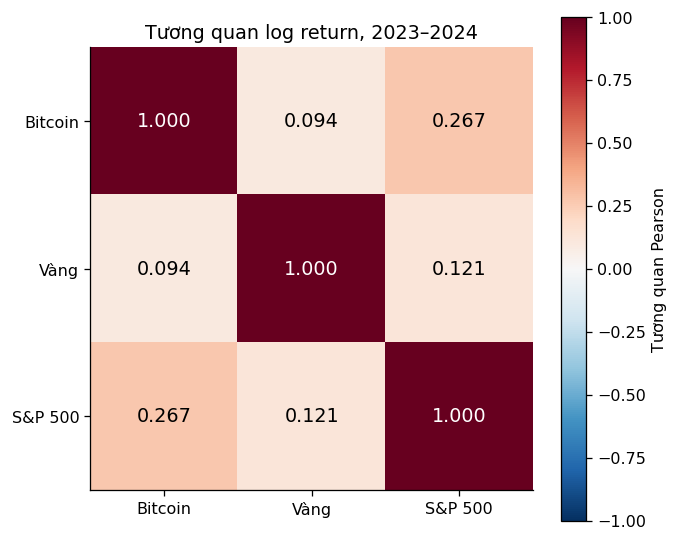

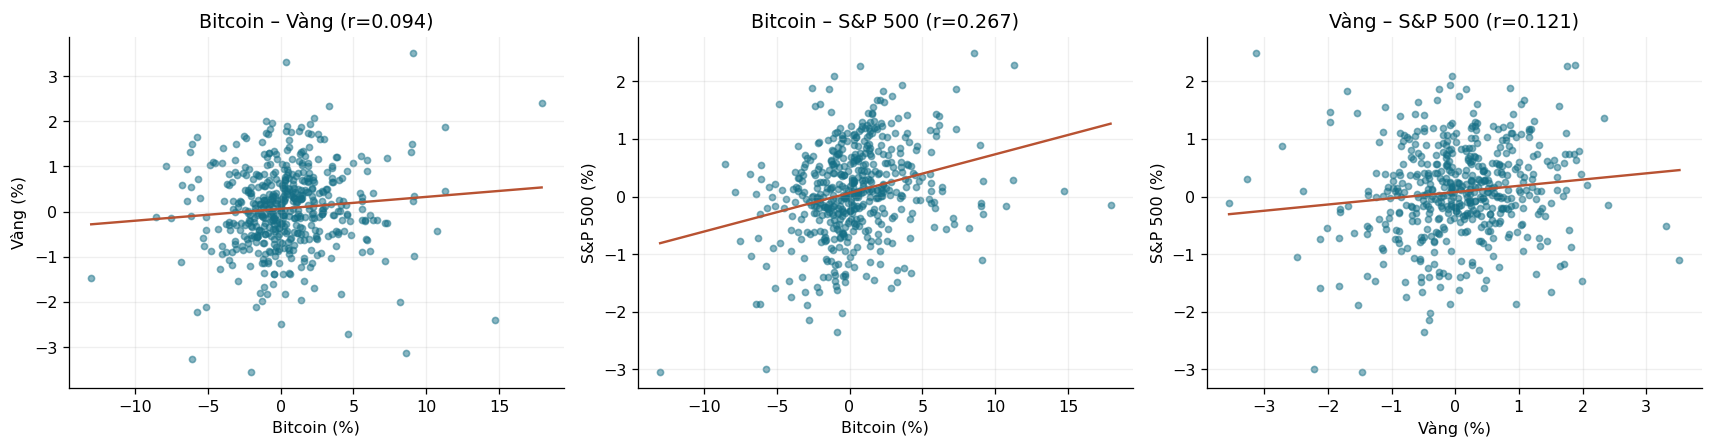

**Nhận xét.** Scatter plot cho thấy mức đồng biến chỉ là một phần của phân phối; các quan sát cực trị không được loại khỏi mẫu.

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(corr.to_numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3), [LABELS[a] for a in ASSETS])
ax.set_yticks(range(3), [LABELS[a] for a in ASSETS])
ax.grid(False)
for i in range(3):
    for j in range(3):
        value = corr.iloc[i, j]
        ax.text(j, i, f'{value:.3f}', ha='center', va='center',
                color='white' if abs(value) > .7 else 'black', fontsize=12)
fig.colorbar(image, ax=ax, label='Tương quan Pearson')
ax.set_title('Tương quan log return, 2023–2024')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (a, b) in zip(axes, [('BTC','GOLD'), ('BTC','SP500'), ('GOLD','SP500')]):
    x, y = returns[a] * 100, returns[b] * 100
    ax.scatter(x, y, alpha=.5, s=15, color='#156f86')
    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, slope * xx + intercept, color='#b85232')
    ax.set(xlabel=f'{LABELS[a]} (%)', ylabel=f'{LABELS[b]} (%)',
           title=f'{LABELS[a]} – {LABELS[b]} (r={corr.loc[a,b]:.3f})')
plt.tight_layout()
plt.show()
note('Scatter plot cho thấy mức đồng biến chỉ là một phần của phân phối; '
     'các quan sát cực trị không được loại khỏi mẫu.')

## P1 – 2.3 Nhận xét về khả năng đa dạng hóa

Cặp tương quan thấp tạo điều kiện đa dạng hóa tốt hơn **khi các yếu tố
khác giữ nguyên**. Không suy ra cặp có tương quan thấp nhất luôn tạo
danh mục có rủi ro tuyệt đối thấp nhất: volatility và trọng số cũng
quyết định covariance và rủi ro danh mục. Phần 2 kiểm tra điều này.

In [7]:
low_pair, high_pair = pair_corr.idxmin(), pair_corr.idxmax()
note(f"Trong mẫu, **{low_pair}** có tương quan thấp nhất ({pair_corr.min():.4f}), "
     f"còn **{high_pair}** cao nhất ({pair_corr.max():.4f}). Theo tiêu chí tương "
     'quan, cặp thứ nhất hỗ trợ đa dạng hóa hơn, còn cặp thứ hai kém hơn. '
     'Đây là đánh giá tương đối trong 2023–2024; chưa thay thế việc tính '
     'variance cho danh mục có trọng số cụ thể.')

**Nhận xét.** Trong mẫu, **BTC–Gold** có tương quan thấp nhất (0.0942), còn **BTC–S&P 500** cao nhất (0.2665). Theo tiêu chí tương quan, cặp thứ nhất hỗ trợ đa dạng hóa hơn, còn cặp thứ hai kém hơn. Đây là đánh giá tương đối trong 2023–2024; chưa thay thế việc tính variance cho danh mục có trọng số cụ thể.

## P2 – 1.1 Trọng số danh mục

Trọng số cơ sở đã được xác nhận: **BTC 20%, Vàng 30%, S&P 500 50%**.
So sánh với chia đều và 10%/40%/50%. Các trọng số không âm, tổng bằng 1.
Phần 3 dùng duy nhất kịch bản cơ sở để giữ đầu vào thống nhất.

In [8]:
assert (weights >= 0).all().all()
np.testing.assert_allclose(weights.sum(axis=1), 1.0)
table(weights * 100, 'Trọng số các kịch bản (%)')
note(f'Danh mục cơ sở dùng {pct(w[0])} BTC, {pct(w[1])} Vàng và {pct(w[2])} S&P 500. '
     'Các kịch bản là giả định minh họa đã chốt, không phải nghiệm tối ưu.')

**Trọng số các kịch bản (%)**

,BTC,GOLD,SP500
Cơ sở 20/30/50,20.000000,30.000000,50.000000
Chia đều,33.333333,33.333333,33.333333
10/40/50,10.000000,40.000000,50.000000


**Nhận xét.** Danh mục cơ sở dùng 20.000% BTC, 30.000% Vàng và 50.000% S&P 500. Các kịch bản là giả định minh họa đã chốt, không phải nghiệm tối ưu.

## P2 – 1.2 Cơ sở lựa chọn trọng số

S&P 500 chiếm 50% để đại diện phần cổ phiếu; vàng 30% bổ sung nguồn
biến động khác; BTC 20% tạo tiếp xúc với tài sản số nhưng hạn chế tỷ trọng
do biến động cao. Đây là giả định minh họa của nhóm, không được suy ra
từ bài toán tối ưu hóa và không phải khuyến nghị đầu tư.

Danh mục chia đều không đồng nghĩa chia đều rủi ro. Kịch bản 10/40/50
giữ phần cổ phiếu, chuyển 10 điểm phần trăm từ BTC sang vàng để xem
ảnh hưởng của trọng số tới volatility.

In [9]:
table(pd.DataFrame({'Vai trò minh họa': ['Tài sản số', 'Đa dạng hóa', 'Cổ phiếu'],
                    'Volatility mẫu/ngày (%)': asset_vol * 100}, index=list(ASSETS)),
      'Vai trò và biến động thực nghiệm')
note(f"Tài sản có volatility lớn nhất là **{LABELS[asset_vol.idxmax()]}** "
     f"({pct(asset_vol.max())}/phiên). Do đó tỷ trọng vốn cần được đọc cùng "
     'đóng góp rủi ro, thay vì giả định chúng tỉ lệ một-một.')

**Vai trò và biến động thực nghiệm**

,Vai trò minh họa,Volatility mẫu/ngày (%)
BTC,Tài sản số,3.225021
GOLD,Đa dạng hóa,0.903376
SP500,Cổ phiếu,0.810776


**Nhận xét.** Tài sản có volatility lớn nhất là **Bitcoin** (3.225%/phiên). Do đó tỷ trọng vốn cần được đọc cùng đóng góp rủi ro, thay vì giả định chúng tỉ lệ một-một.

## P2 – 1.3 Ma trận hiệp phương sai

Covariance mẫu dùng $n-1$ ở mẫu số (`ddof=1`), đơn vị log return bình phương:

$$\widehat\Sigma_{ij}=\frac{1}{n-1}\sum_t(r_{i,t}-\bar r_i)(r_{j,t}-\bar r_j).$$

Với giả định độc lập và ổn định theo thời gian,
$\Sigma_{\mathrm{năm}}=252\Sigma_{\mathrm{ngày}}$.
Đối chiếu $\Sigma_{ij}=\rho_{ij}\sigma_i\sigma_j$ để kiểm tra nhất quán.

In [10]:
sigma_annual = DAYS * sigma
table(sigma, 'Covariance/ngày (log return²)')
table(sigma_annual, 'Covariance/năm (log return²)')
reconstructed = corr.to_numpy() * np.outer(asset_vol, asset_vol)
np.testing.assert_allclose(sigma.to_numpy(), reconstructed, atol=1e-14)
covariance_error = float(np.max(np.abs(sigma.to_numpy() - reconstructed)))
eigenvalues = np.linalg.eigvalsh(sigma.to_numpy())
if not np.all(eigenvalues > 0):
    raise ValueError('Covariance không xác định dương; không thể dùng Cholesky.')
note(f'Sai lệch tái dựng covariance từ correlation là {covariance_error:.2e}. '
     f'Trị riêng nhỏ nhất {eigenvalues.min():.6g} > 0, phù hợp để mô phỏng Cholesky.')

**Covariance/ngày (log return²)**

,BTC,GOLD,SP500
BTC,0.001040,0.000027,0.000070
GOLD,0.000027,0.000082,0.000009
SP500,0.000070,0.000009,0.000066


**Covariance/năm (log return²)**

,BTC,GOLD,SP500
BTC,0.262099,0.006917,0.017562
GOLD,0.006917,0.020565,0.002224
SP500,0.017562,0.002224,0.016565


**Nhận xét.** Sai lệch tái dựng covariance từ correlation là 2.17e-19. Trị riêng nhỏ nhất 5.86548e-05 > 0, phù hợp để mô phỏng Cholesky.

## P2 – 2.1 Portfolio Return

Trong mô hình tuyến tính đã chọn:

$$E[r_p]=\sum_iw_i\mu_i=w^\top\mu,\qquad \mu_{p,\mathrm{năm}}=252\mu_{p,\mathrm{ngày}}.$$

Bảng ghi rõ **kỳ vọng log return**, không xem con số năm là mức tăng vốn
đơn chắc chắn. Các tham số là ước lượng từ mẫu, không phải dự báo năm 2026.

In [11]:
portfolio_history = returns.to_numpy() @ w
mu_p = float(w @ mu.to_numpy())
portfolio_means = weights.to_numpy() @ mu.to_numpy()
return_table = pd.DataFrame({'Mean log return/ngày (%)': portfolio_means * 100,
                             'Mean log return/năm (%)': portfolio_means * DAYS * 100},
                            index=weights.index)
table(return_table, 'Kỳ vọng log return của ba danh mục')
np.testing.assert_allclose(portfolio_history.mean(), mu_p)
note(f'Danh mục cơ sở có kỳ vọng log return {pct(mu_p)}/phiên và '
     f'{pct(mu_p * DAYS)}/năm theo quy tắc 252 phiên. Đây là kỳ vọng của '
     'biến log return xấp xỉ; không phải lời hứa về mức lợi nhuận.')

**Kỳ vọng log return của ba danh mục**

,Mean log return/ngày (%),Mean log return/năm (%)
Cơ sở 20/30/50,0.133081,33.536320
Chia đều,0.167023,42.089698
10/40/50,0.105744,26.647458


**Nhận xét.** Danh mục cơ sở có kỳ vọng log return 0.133%/phiên và 33.536%/năm theo quy tắc 252 phiên. Đây là kỳ vọng của biến log return xấp xỉ; không phải lời hứa về mức lợi nhuận.

## P2 – 2.2 Portfolio Variance

Khai triển cho ba tài sản:

$$\sigma_p^2=w_B^2\sigma_B^2+w_G^2\sigma_G^2+w_S^2\sigma_S^2
+2w_Bw_G\sigma_{BG}+2w_Bw_S\sigma_{BS}+2w_Gw_S\sigma_{GS}=w^\top\Sigma w.$$

Đối chiếu tổng khai triển, dạng ma trận và variance của chuỗi lịch sử
$r_{p,t}=w^\top r_t$ (cùng `ddof=1`). Variance năm bằng 252 lần variance ngày.

In [12]:
cov = sigma.to_numpy()
own_variance = float(np.sum(w**2 * np.diag(cov)))
cross_terms = {f'{ASSETS[i]}–{ASSETS[j]}': float(2*w[i]*w[j]*cov[i,j])
               for i in range(3) for j in range(i+1,3)}
covariance_variance = sum(cross_terms.values())
var_p = float(w @ cov @ w)
var_expanded = own_variance + covariance_variance
historical_var = float(np.var(portfolio_history, ddof=1))
np.testing.assert_allclose([var_expanded, historical_var], var_p, atol=1e-14)
table(pd.DataFrame({'Variance/ngày': [var_expanded, var_p, historical_var],
                    'Variance/năm': np.array([var_expanded, var_p, historical_var])*DAYS},
                   index=['Khai triển', 'wᵀΣw', 'Chuỗi lịch sử']),
      'Đối chiếu ba cách tính variance')
note(f'Ba cách thống nhất ở variance/ngày **{var_p:.8f}**; '
     f'variance/năm là **{var_p * DAYS:.8f}**.')

**Đối chiếu ba cách tính variance**

,Variance/ngày,Variance/năm
Khai triển,0.000085,0.021486
wᵀΣw,0.000085,0.021486
Chuỗi lịch sử,0.000085,0.021486


**Nhận xét.** Ba cách thống nhất ở variance/ngày **0.00008526**; variance/năm là **0.02148607**.

## P2 – 2.3 Portfolio Standard Deviation (Volatility)

Volatility là căn bậc hai của variance:

$$\sigma_p=\sqrt{w^\top\Sigma w},\qquad
\sigma_{p,\mathrm{năm}}=\sqrt{252}\,\sigma_{p,\mathrm{ngày}}.$$

Quy tắc căn thời gian chỉ là phép quy đổi theo các giả định chung;
không mô phỏng trực tiếp một năm hoặc xét volatility clustering.

In [13]:
vol_p = float(np.sqrt(var_p))
scenario_vars = np.einsum('ij,jk,ik->i', weights.to_numpy(), cov, weights.to_numpy())
scenario_vols = np.sqrt(scenario_vars)
scenario_table = return_table.copy()
scenario_table['Variance/ngày'] = scenario_vars
scenario_table['Volatility/ngày (%)'] = scenario_vols * 100
scenario_table['Volatility/năm (%)'] = scenario_vols * np.sqrt(DAYS) * 100
table(scenario_table, 'So sánh return và rủi ro theo trọng số')
note(f'Volatility cơ sở là **{pct(vol_p)}/phiên**, tương đương '
     f'**{pct(vol_p*np.sqrt(DAYS))}/năm** theo giả định 252 phiên.')

**So sánh return và rủi ro theo trọng số**

,Mean log return/ngày (%),Mean log return/năm (%),Variance/ngày,Volatility/ngày (%),Volatility/năm (%)
Cơ sở 20/30/50,0.133081,33.536320,0.000085,0.923375,14.658126
Chia đều,0.167023,42.089698,0.000155,1.246933,19.794445
10/40/50,0.105744,26.647458,0.000053,0.725176,11.511818


**Nhận xét.** Volatility cơ sở là **0.923%/phiên**, tương đương **14.658%/năm** theo giả định 252 phiên.

## P2 – 3.1 So sánh volatility của danh mục với volatility của từng tài sản

Với trọng số không âm có tổng bằng 1 và $\rho_{ij}\le1$:

$$\sigma_p^2\le\left(\sum_i w_i\sigma_i\right)^2,
\qquad\sigma_p\le\sum_iw_i\sigma_i.$$

Bất đẳng thức là nghiêm khi có cặp mang trọng số dương, volatility dương
và tương quan nhỏ hơn 1. Mốc so sánh là **trung bình volatility có trọng
số**, không yêu cầu danh mục ít biến động hơn mọi tài sản riêng lẻ.

**Volatility tài sản và danh mục**

,Volatility/ngày (%),Volatility/năm (%)
BTC,3.225021,51.195615
GOLD,0.903376,14.340647
SP500,0.810776,12.870672
Danh mục cơ sở,0.923375,14.658126
Trung bình volatility có trọng số,1.321405,20.976653


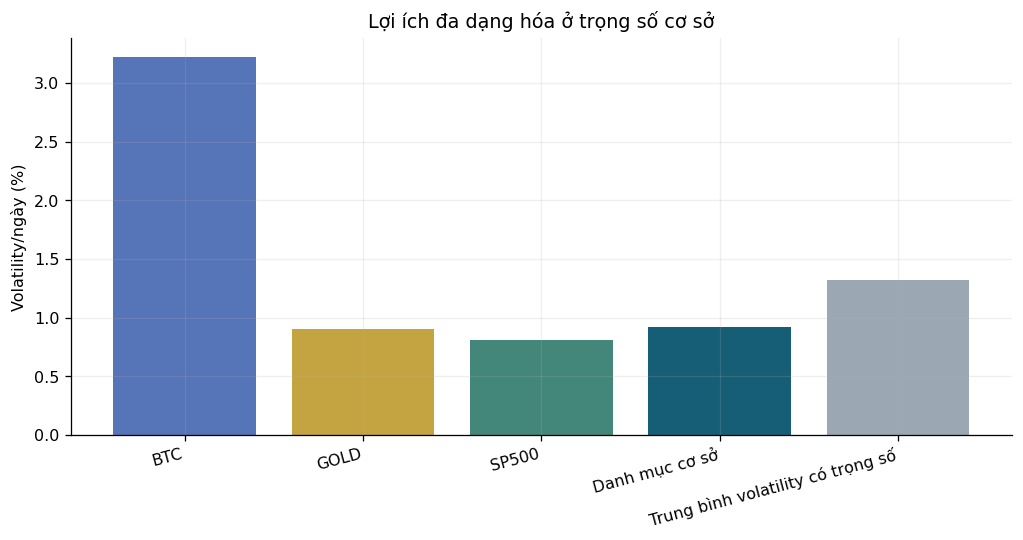

**Nhận xét.** 0.923% < 1.321%: volatility danh mục thấp hơn mốc trung bình có trọng số **30.122%**. Điều này không đồng nghĩa danh mục an toàn hơn riêng vàng hay riêng S&P 500.

In [14]:
weighted_vol = float(w @ asset_vol.to_numpy())
vol_comparison = pd.DataFrame({'Volatility/ngày (%)': [*list(asset_vol*100),
                              vol_p*100, weighted_vol*100]},
                             index=[*list(ASSETS), 'Danh mục cơ sở',
                                    'Trung bình volatility có trọng số'])
vol_comparison['Volatility/năm (%)'] = vol_comparison.iloc[:,0] * np.sqrt(DAYS)
table(vol_comparison, 'Volatility tài sản và danh mục')
assert vol_p < weighted_vol
diversification_reduction = 1 - vol_p / weighted_vol
fig, ax = plt.subplots()
ax.bar(vol_comparison.index, vol_comparison.iloc[:,0],
       color=['#5674b8','#c4a440','#42877a','#155e75','#9ba8b3'])
ax.set_ylabel('Volatility/ngày (%)')
ax.set_title('Lợi ích đa dạng hóa ở trọng số cơ sở')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()
note(f'{pct(vol_p)} < {pct(weighted_vol)}: volatility danh mục thấp hơn mốc '
     f'trung bình có trọng số **{pct(diversification_reduction)}**. '
     'Điều này không đồng nghĩa danh mục an toàn hơn riêng vàng hay riêng S&P 500.')

## P2 – 3.2 Vai trò của trọng số, phương sai và hiệp phương sai

Phân rã variance thành $\sum_i w_i^2\sigma_i^2$ và
$2\sum_{i<j}w_iw_j\sigma_{ij}$. Đóng góp vào volatility theo Euler:

$$RC_i=\frac{w_i(\Sigma w)_i}{\sigma_p},\quad
\sum_iRC_i=\sigma_p,\quad \text{Tỷ lệ đóng góp}_i=RC_i/\sigma_p.$$

Các covariance tác động đồng thời tới đóng góp của mỗi tài sản.
Tỷ trọng vốn nhỏ vẫn có thể tạo đóng góp rủi ro lớn nếu volatility cao.

In [15]:
components = pd.Series({'Phương sai riêng': own_variance, **cross_terms})
table(pd.DataFrame({'Variance/ngày': components,
                    'Tỷ lệ variance (%)': components/var_p*100}),
      'Phân rã variance cơ sở')
rc = w * (cov @ w) / vol_p
np.testing.assert_allclose(rc.sum(), vol_p, atol=1e-14)
risk_contributions = pd.DataFrame({'Trọng số (%)': w*100,
                                   'RC volatility/ngày (điểm %)': rc*100,
                                   'Tỷ lệ đóng góp rủi ro (%)': rc/vol_p*100},
                                  index=list(ASSETS))
table(risk_contributions, 'Đóng góp rủi ro từng tài sản')
largest_rc = risk_contributions['Tỷ lệ đóng góp rủi ro (%)'].idxmax()
lowest_vol_scenario = scenario_table['Volatility/ngày (%)'].idxmin()
note(f'Phần variance riêng chiếm {own_variance/var_p:.2%}, covariance chiếm '
     f'{covariance_variance/var_p:.2%}. {LABELS[largest_rc]} đóng góp rủi ro '
     f'lớn nhất ({risk_contributions.loc[largest_rc, "Tỷ lệ đóng góp rủi ro (%)"]:.2f}%). '
     f'Trong ba kịch bản, **{lowest_vol_scenario}** có volatility thấp nhất; '
     'kết quả chỉ so sánh các giả định đã chọn, không chứng minh tối ưu toàn cục.')

**Phân rã variance cơ sở**

,Variance/ngày,Tỷ lệ variance (%)
Phương sai riêng,0.000065,76.683210
BTC–GOLD,0.000003,3.863387
BTC–SP500,0.000014,16.347556
GOLD–SP500,0.000003,3.105847


**Đóng góp rủi ro từng tài sản**

,Trọng số (%),RC volatility/ngày (điểm %),Tỷ lệ đóng góp rủi ro (%)
BTC,20.0,0.543865,58.899715
GOLD,30.0,0.111719,12.098978
SP500,50.0,0.267791,29.001307


**Nhận xét.** Phần variance riêng chiếm 76.68%, covariance chiếm 23.32%. Bitcoin đóng góp rủi ro lớn nhất (58.90%). Trong ba kịch bản, **10/40/50** có volatility thấp nhất; kết quả chỉ so sánh các giả định đã chọn, không chứng minh tối ưu toàn cục.

## P3 – 1.1 Input và tham số mô phỏng

Dùng nguyên vector $\mu$, covariance $\Sigma$ **theo phiên** và trọng số
cơ sở từ Phần 2. Không dùng covariance năm cho mô phỏng một phiên.
Mọi kịch bản bắt đầu với vốn 100.000 USD và không thêm yếu tố tỷ giá.

In [16]:
table(pd.DataFrame({'Mean log return/ngày': mu, 'Trọng số': w,
                    'Volatility/ngày': asset_vol}), 'Đầu vào theo tài sản')
table(sigma, 'Covariance/ngày dùng cho mô phỏng')
table(pd.DataFrame({'Giá trị': [CAPITAL, 1, CONFIDENCE, N_SIM, SEED, len(returns)]},
                   index=['Vốn USD', 'Horizon (phiên chung)', 'Mức tin cậy',
                          'Mô phỏng/phương pháp', 'Seed', 'Quan sát lịch sử']),
      'Input chung')
note('Các tham số được lấy trực tiếp từ Phần 2; do đó chênh lệch giữa hai '
     'phương pháp ở Phần 3 phản ánh cơ chế sinh mẫu và giả định phân phối.')

**Đầu vào theo tài sản**

,Mean log return/ngày,Trọng số,Volatility/ngày
BTC,0.003443,0.2,0.032250
GOLD,0.000709,0.3,0.009034
SP500,0.000859,0.5,0.008108


**Covariance/ngày dùng cho mô phỏng**

,BTC,GOLD,SP500
BTC,0.001040,0.000027,0.000070
GOLD,0.000027,0.000082,0.000009
SP500,0.000070,0.000009,0.000066


**Input chung**

,Giá trị
Vốn USD,100000.00
Horizon (phiên chung),1.00
Mức tin cậy,0.95
Mô phỏng/phương pháp,100000.00
Seed,42.00
Quan sát lịch sử,501.00


**Nhận xét.** Các tham số được lấy trực tiếp từ Phần 2; do đó chênh lệch giữa hai phương pháp ở Phần 3 phản ánh cơ chế sinh mẫu và giả định phân phối.

## P3 – 1.2 Phương pháp mô phỏng và giả định phân phối

**Chuẩn đa biến:** $r\sim N_3(\mu,\Sigma)$, thuận tiện để giữ mean,
covariance và cấu trúc tương quan tuyến tính. Phân phối chuẩn đối xứng,
không mô hình hóa riêng skewness, đuôi dày hoặc volatility clustering.

**Bootstrap lịch sử:** lấy mẫu nguyên vector return của một phiên với
xác suất như nhau, có hoàn lại. Phương pháp giữ phân phối thực nghiệm
và phụ thuộc cùng phiên, nhưng không sinh các cú sốc ngoài mẫu và
không giữ thứ tự/phụ thuộc thời gian. Hai phương pháp đều giả định
mẫu 2023–2024 đại diện cho kỳ rủi ro đang xét.

In [17]:
method_table = pd.DataFrame({
    'Cơ chế': ['N₃(μ,Σ), Cholesky', 'Lấy nguyên hàng return, có hoàn lại'],
    'Giữ phụ thuộc cùng phiên': ['Covariance tuyến tính', 'Vector thực nghiệm'],
    'Giới hạn chính': ['Chuẩn đối xứng, đuôi nhẹ', 'Không có cú sốc ngoài lịch sử']},
    index=['Chuẩn đa biến', 'Bootstrap lịch sử'])
table(method_table, 'Hai giả định phân phối')
note('Bootstrap ở đây sinh kịch bản lợi nhuận một phiên, không phải bootstrap '
     'để lập khoảng tin cậy cho một ước lượng. Không giả định trước phương pháp nào '
     'cho VaR hoặc ES cao hơn.')

**Hai giả định phân phối**

,Cơ chế,Giữ phụ thuộc cùng phiên,Giới hạn chính
Chuẩn đa biến,"N₃(μ,Σ), Cholesky",Covariance tuyến tính,"Chuẩn đối xứng, đuôi nhẹ"
Bootstrap lịch sử,"Lấy nguyên hàng return, có hoàn lại",Vector thực nghiệm,Không có cú sốc ngoài lịch sử


**Nhận xét.** Bootstrap ở đây sinh kịch bản lợi nhuận một phiên, không phải bootstrap để lập khoảng tin cậy cho một ước lượng. Không giả định trước phương pháp nào cho VaR hoặc ES cao hơn.

## P3 – 1.3 Số lần mô phỏng và cơ chế mô phỏng

Sinh 100.000 kịch bản mỗi phương pháp với seed cố định 42. Với
$\Sigma=LL^\top$, $Z\sim N(0,I_3)$, đặt:

$$r^{(s)}=\mu+LZ^{(s)},\qquad r_p^{(s)}=w^\top r^{(s)}.$$

Trong biểu diễn ma trận hàng, dùng `Z @ L.T`. Kiểm tra covariance
xác định dương; không tự sửa covariance bằng jitter.
[Tài liệu Cholesky của NumPy](https://numpy.org/doc/2.2/reference/generated/numpy.linalg.cholesky.html).

Bootstrap lấy **cùng một chỉ số hàng cho cả ba tài sản**. Hai generator
riêng cùng seed giúp tái lập từng phương pháp độc lập với thứ tự chạy.

In [18]:
if not np.all(np.linalg.eigvalsh(cov) > 0):
    raise ValueError('Covariance phải xác định dương để dùng Cholesky.')
L = np.linalg.cholesky(cov)
np.testing.assert_allclose(L @ L.T, cov, atol=1e-14)
normal_rng = np.random.default_rng(SEED)
normal_assets = mu.to_numpy() + normal_rng.standard_normal((N_SIM, 3)) @ L.T
bootstrap_rng = np.random.default_rng(SEED)
sampled_rows = bootstrap_rng.integers(0, len(returns), size=N_SIM)
bootstrap_assets = returns.to_numpy()[sampled_rows]
simulations = {'Chuẩn đa biến': normal_assets @ w,
               'Bootstrap lịch sử': bootstrap_assets @ w}
assert all(len(values) == N_SIM for values in simulations.values())
normal_replay = mu.to_numpy() + np.random.default_rng(SEED).standard_normal((N_SIM, 3)) @ L.T
bootstrap_replay_rows = np.random.default_rng(SEED).integers(0, len(returns), size=N_SIM)
np.testing.assert_array_equal(normal_assets, normal_replay)
np.testing.assert_array_equal(sampled_rows, bootstrap_replay_rows)
note(f'Đã sinh {N_SIM:,} kịch bản cho mỗi phương pháp. Cholesky tái dựng '
     'đúng covariance; kiểm tra chạy lại với seed 42 cho kết quả giống nhau '
     'trong cùng môi trường. Bootstrap không lấy mẫu từng cột độc lập.')

**Nhận xét.** Đã sinh 100,000 kịch bản cho mỗi phương pháp. Cholesky tái dựng đúng covariance; kiểm tra chạy lại với seed 42 cho kết quả giống nhau trong cùng môi trường. Bootstrap không lấy mẫu từng cột độc lập.

## P3 – 1.4 Phân phối lợi nhuận danh mục mô phỏng

Histogram biểu diễn **log return xấp xỉ**, cùng đơn vị với Phần 2.
Kiểm tra mean và SD mô phỏng với mốc lý thuyết. Chuẩn đa biến dùng
$\mu_p,\sigma_p$. Bootstrap dùng mean lịch sử và SD thực nghiệm `ddof=0`:

$$\sigma_{\mathrm{emp}}=\sqrt{\frac{n-1}{n}}\,\sigma_p.$$

Ngưỡng kiểm tra mean là năm sai số chuẩn $5\sigma/\sqrt{N}$, còn sai
lệch tương đối SD không quá 1%. Đây là kiểm tra sinh mẫu, không chứng
minh phân phối phù hợp với tương lai.

**Đối chiếu mô phỏng với Phần 2 và phân phối thực nghiệm**

,Mean mô phỏng (%),Mean mốc (%),SD mô phỏng (%),SD mốc (%),Sai lệch mean/SE,Sai lệch SD (%)
Phương pháp,,,,,,
Chuẩn đa biến,0.132461,0.133081,0.926658,0.923375,0.212142,0.355533
Bootstrap lịch sử,0.133538,0.133081,0.925282,0.922453,0.156849,0.306680


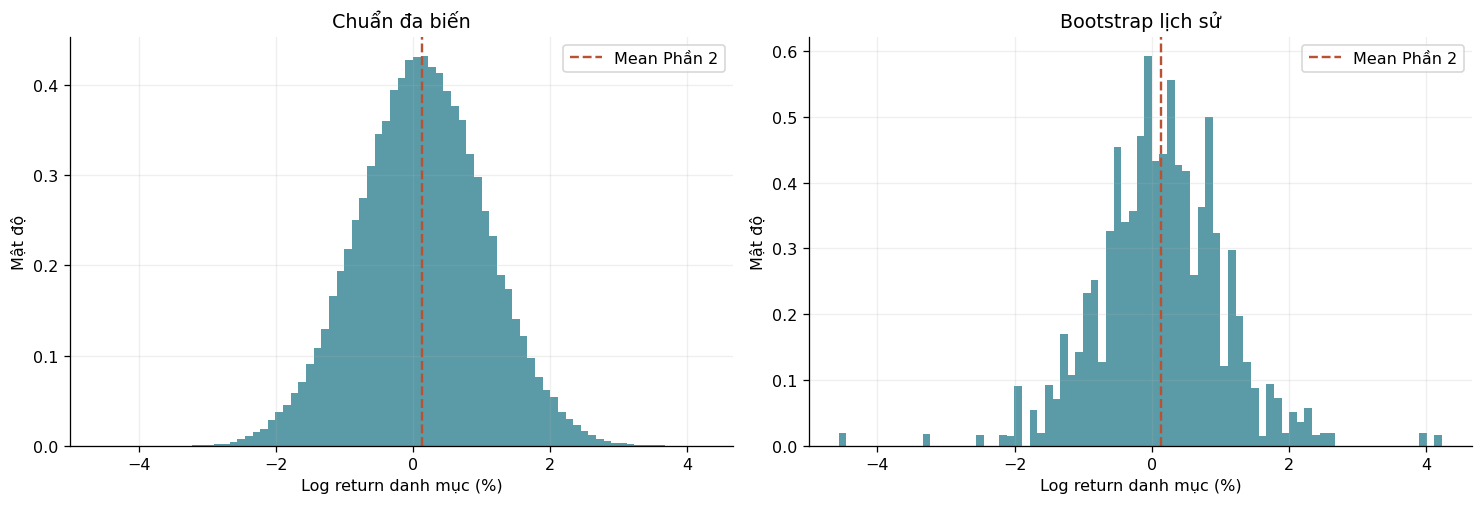

**Nhận xét.** Cả hai phương pháp đạt kiểm tra mean và SD. Hình dạng histogram có thể khác nhau dù các moment gần nhau; bootstrap một phiên rút từ tập hữu hạn các return nên phân phối thực chất rời rạc.

In [19]:
simulated_moments = []
for name, values in simulations.items():
    reference_mean = mu_p
    reference_sd = vol_p if name == 'Chuẩn đa biến' else float(np.std(portfolio_history, ddof=0))
    simulated_mean = float(values.mean())
    simulated_sd = float(values.std(ddof=0))
    mean_error = abs(simulated_mean - reference_mean)
    sd_relative_error = abs(simulated_sd / reference_sd - 1)
    mean_bound = 5 * reference_sd / np.sqrt(N_SIM)
    assert mean_error <= mean_bound, f'{name}: mean vượt 5 sai số chuẩn'
    assert sd_relative_error <= .01, f'{name}: SD sai lệch quá 1%'
    simulated_moments.append({'Phương pháp': name,
        'Mean mô phỏng (%)': simulated_mean*100, 'Mean mốc (%)': reference_mean*100,
        'SD mô phỏng (%)': simulated_sd*100, 'SD mốc (%)': reference_sd*100,
        'Sai lệch mean/SE': mean_error/(reference_sd/np.sqrt(N_SIM)),
        'Sai lệch SD (%)': sd_relative_error*100})
moment_table = pd.DataFrame(simulated_moments).set_index('Phương pháp')
table(moment_table, 'Đối chiếu mô phỏng với Phần 2 và phân phối thực nghiệm')
bins = np.linspace(min(v.min() for v in simulations.values())*100,
                   max(v.max() for v in simulations.values())*100, 80)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, (name, values) in zip(axes, simulations.items()):
    ax.hist(values*100, bins=bins, density=True, color='#237a8a', alpha=.75)
    ax.axvline(mu_p*100, color='#b85232', linestyle='--', label='Mean Phần 2')
    ax.set(title=name, xlabel='Log return danh mục (%)', ylabel='Mật độ')
    ax.legend()
plt.tight_layout()
plt.show()
note('Cả hai phương pháp đạt kiểm tra mean và SD. Hình dạng histogram có thể '
     'khác nhau dù các moment gần nhau; bootstrap một phiên rút từ tập hữu '
     'hạn các return nên phân phối thực chất rời rạc.')

## P3 – 2.1 Value at Risk 95%

Với $q_{0.05}$ là phân vị 5% của log return mô phỏng:

$$L^{(s)}=-V_0(e^{r_p^{(s)}}-1),\qquad
VaR_{95\%}=-V_0(e^{q_{0.05}}-1).$$

Dùng phân vị nội suy tuyến tính và `expm1` để tính $e^r-1$ chính xác
về số học. Dấu dương biểu thị tổn thất. Theo mô hình, khoảng 5% kịch bản
có lỗ chạm/vượt ngưỡng VaR; VaR không phải mức lỗ tối đa. Không cắt
VaR âm về 0 nếu bộ dữ liệu khác cho phân vị return dương.

**VaR một phiên, vốn 100.000 USD**

,Phân vị 5% log return (%),VaR 95% (% vốn),VaR 95% (USD)
Phương pháp,,,
Chuẩn đa biến,-1.391808,1.382168,1382.167529
Bootstrap lịch sử,-1.304284,1.295815,1295.815245


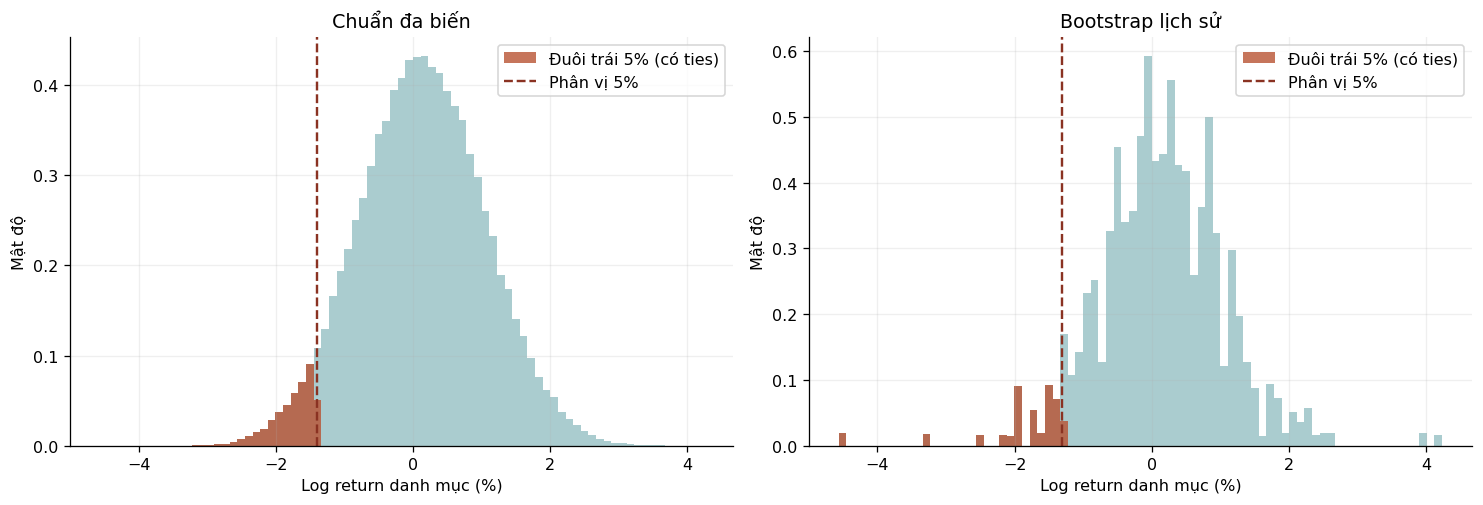

**Nhận xét.** **Chuẩn đa biến: VaR = 1,382.17 USD (1.382% vốn)** cho một phiên chung. Ngưỡng này được vượt trong khoảng 5% kịch bản của mô hình, không đặt trần cho tổn thất thực tế.

**Nhận xét.** **Bootstrap lịch sử: VaR = 1,295.82 USD (1.296% vốn)** cho một phiên chung. Ngưỡng này được vượt trong khoảng 5% kịch bản của mô hình, không đặt trần cho tổn thất thực tế.

In [20]:
risk_results = {}
for name, values in simulations.items():
    quantile = float(np.quantile(values, 1-CONFIDENCE, method='linear'))
    losses = -CAPITAL * np.expm1(values)
    value_at_risk = float(-CAPITAL * np.expm1(quantile))
    risk_results[name] = {'quantile_log_return': quantile,
                          'var_usd': value_at_risk, 'losses': losses}
var_table = pd.DataFrame([
    {'Phương pháp': name, 'Phân vị 5% log return (%)': r['quantile_log_return']*100,
     'VaR 95% (% vốn)': r['var_usd']/CAPITAL*100, 'VaR 95% (USD)': r['var_usd']}
    for name, r in risk_results.items()]).set_index('Phương pháp')
table(var_table, 'VaR một phiên, vốn 100.000 USD')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, (name, values) in zip(axes, simulations.items()):
    threshold = risk_results[name]['quantile_log_return']
    ax.hist(values*100, bins=bins, density=True, color='#95c0c4', alpha=.8)
    ax.hist(values[values <= threshold]*100, bins=bins, density=False,
            weights=np.ones(np.sum(values<=threshold))/(N_SIM*(bins[1]-bins[0])),
            color='#b85232', alpha=.8, label='Đuôi trái 5% (có ties)')
    ax.axvline(threshold*100, color='#8a3222', linestyle='--', label='Phân vị 5%')
    ax.set(title=name, xlabel='Log return danh mục (%)', ylabel='Mật độ')
    ax.legend()
plt.tight_layout()
plt.show()
for name, result in risk_results.items():
    note(f"**{name}: VaR = {result['var_usd']:,.2f} USD "
         f"({result['var_usd']/CAPITAL:.3%} vốn)** cho một phiên chung. "
         'Ngưỡng này được vượt trong khoảng 5% kịch bản của mô hình, '
         'không đặt trần cho tổn thất thực tế.')

## P3 – 2.2 Expected Shortfall (ES) 95%

ES mô tả mức độ nghiêm trọng của các kịch bản nằm trong đuôi tổn thất:

$$ES_{95\%}=\operatorname{mean}\{L^{(s)}:L^{(s)}\ge VaR_{95\%}\}.$$

Quy ước tính **cả quan sát bằng ngưỡng**. Bootstrap có giá trị lặp nên
số quan sát trong đuôi có thể lớn hơn đúng 5% tổng mẫu; báo riêng số
lượng và tỷ lệ. Đây là trung bình có điều kiện theo ngưỡng đã chọn.

In [21]:
for name, result in risk_results.items():
    tail = result['losses'][result['losses'] >= result['var_usd']]
    if not len(tail):
        raise ValueError(f'{name}: đuôi tổn thất rỗng')
    result['es_usd'] = float(tail.mean())
    result['tail_count'] = len(tail)
    result['tail_fraction'] = len(tail)/N_SIM
    assert result['es_usd'] >= result['var_usd']
es_table = pd.DataFrame([
    {'Phương pháp': name, 'ES 95% (USD)': r['es_usd'],
     'ES 95% (% vốn)': r['es_usd']/CAPITAL*100,
     'Số kịch bản đuôi': r['tail_count'], 'Tỷ lệ đuôi (%)': r['tail_fraction']*100}
    for name,r in risk_results.items()]).set_index('Phương pháp')
table(es_table, 'ES và số quan sát đuôi')
for name, result in risk_results.items():
    note(f"**{name}: ES = {result['es_usd']:,.2f} USD** trên "
         f"{result['tail_count']:,} kịch bản ({result['tail_fraction']:.3%}) "
         'có lỗ chạm/vượt VaR. Đây là lỗ trung bình trong đuôi, không phải '
         'lỗ trung bình của tất cả kịch bản.')

**ES và số quan sát đuôi**

,ES 95% (USD),ES 95% (% vốn),Số kịch bản đuôi,Tỷ lệ đuôi (%)
Phương pháp,,,,
Chuẩn đa biến,1764.343508,1.764344,5000,5.000
Bootstrap lịch sử,1852.064037,1.852064,5026,5.026


**Nhận xét.** **Chuẩn đa biến: ES = 1,764.34 USD** trên 5,000 kịch bản (5.000%) có lỗ chạm/vượt VaR. Đây là lỗ trung bình trong đuôi, không phải lỗ trung bình của tất cả kịch bản.

**Nhận xét.** **Bootstrap lịch sử: ES = 1,852.06 USD** trên 5,026 kịch bản (5.026%) có lỗ chạm/vượt VaR. Đây là lỗ trung bình trong đuôi, không phải lỗ trung bình của tất cả kịch bản.

## P3 – 2.3 So sánh VaR và ES

VaR là ngưỡng phân vị, ES là trung bình tổn thất trong đuôi. Với quy ước
đã dùng, $ES\ge VaR$. Khoảng cách ES−VaR cho biết tổn thất vượt ngưỡng
nghiêm trọng đến mức nào trong phân phối mô hình.

**So sánh VaR và ES của cùng danh mục**

,VaR 95% (USD),ES 95% (USD),ES−VaR (USD),VaR 95% (% vốn),ES 95% (% vốn)
Phương pháp,,,,,
Chuẩn đa biến,1382.167529,1764.343508,382.175979,1.382168,1.764344
Bootstrap lịch sử,1295.815245,1852.064037,556.248791,1.295815,1.852064


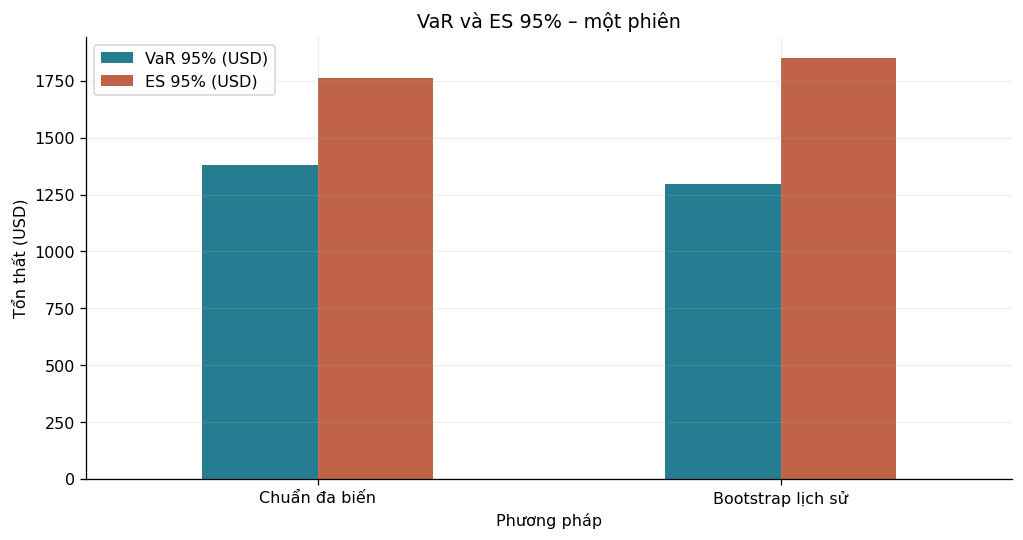

**Nhận xét.** Chuẩn đa biến: ES cao hơn VaR 382.18 USD; Bootstrap lịch sử: ES cao hơn VaR 556.25 USD. ES bổ sung mức độ nghiêm trọng mà riêng ngưỡng VaR không mô tả.

In [22]:
risk_table = pd.DataFrame([
    {'Phương pháp': name, 'VaR 95% (USD)': r['var_usd'],
     'ES 95% (USD)': r['es_usd'], 'ES−VaR (USD)': r['es_usd']-r['var_usd'],
     'VaR 95% (% vốn)': r['var_usd']/CAPITAL*100,
     'ES 95% (% vốn)': r['es_usd']/CAPITAL*100}
    for name,r in risk_results.items()]).set_index('Phương pháp')
table(risk_table, 'So sánh VaR và ES của cùng danh mục')
ax = risk_table[['VaR 95% (USD)','ES 95% (USD)']].plot.bar(
    color=['#267d91','#bf6245'], rot=0)
ax.set(title='VaR và ES 95% – một phiên', ylabel='Tổn thất (USD)')
plt.tight_layout()
plt.show()
note('; '.join(f"{name}: ES cao hơn VaR {r['es_usd']-r['var_usd']:,.2f} USD"
               for name,r in risk_results.items()) +
     '. ES bổ sung mức độ nghiêm trọng mà riêng ngưỡng VaR không mô tả.')

## P3 – 3.1 Ảnh hưởng của giả định phân phối đến VaR & ES

So sánh cùng dữ liệu, trọng số, vốn, horizon và số mô phỏng. Khác biệt
giữa kết quả chuẩn đa biến và bootstrap phản ánh giả định phân phối
và sai số Monte Carlo. Không áp đặt trước bootstrap luôn có VaR/ES lớn
hơn: hai ngưỡng đo các đặc điểm khác nhau của đuôi thực nghiệm.

In [23]:
table(risk_table, 'VaR/ES theo hai giả định phân phối')
normal_risk = risk_results['Chuẩn đa biến']
bootstrap_risk = risk_results['Bootstrap lịch sử']
for metric, label in [('var_usd','VaR'), ('es_usd','ES')]:
    difference = bootstrap_risk[metric] - normal_risk[metric]
    direction = 'cao hơn' if difference > 0 else ('thấp hơn' if difference < 0 else 'bằng')
    note(f'Bootstrap cho **{label} {direction}** chuẩn đa biến '
         f'{abs(difference):,.2f} USD. Kết quả được đọc từ mô phỏng, '
         'không từ giả định rằng một phương pháp luôn bảo thủ hơn.')
note('Monte Carlo chỉ phản ánh mô hình đầu vào. Tăng số mô phỏng giảm '
     'sai số lấy mẫu nhưng không sửa được phân phối sai hoặc lịch sử thiếu đại diện.')

**VaR/ES theo hai giả định phân phối**

,VaR 95% (USD),ES 95% (USD),ES−VaR (USD),VaR 95% (% vốn),ES 95% (% vốn)
Phương pháp,,,,,
Chuẩn đa biến,1382.167529,1764.343508,382.175979,1.382168,1.764344
Bootstrap lịch sử,1295.815245,1852.064037,556.248791,1.295815,1.852064


**Nhận xét.** Bootstrap cho **VaR thấp hơn** chuẩn đa biến 86.35 USD. Kết quả được đọc từ mô phỏng, không từ giả định rằng một phương pháp luôn bảo thủ hơn.

**Nhận xét.** Bootstrap cho **ES cao hơn** chuẩn đa biến 87.72 USD. Kết quả được đọc từ mô phỏng, không từ giả định rằng một phương pháp luôn bảo thủ hơn.

**Nhận xét.** Monte Carlo chỉ phản ánh mô hình đầu vào. Tăng số mô phỏng giảm sai số lấy mẫu nhưng không sửa được phân phối sai hoặc lịch sử thiếu đại diện.

## P3 – 3.2 Hạn chế dữ liệu lịch sử

Mẫu chỉ gồm hai năm 2023–2024, không bao phủ các giai đoạn khủng hoảng
lớn ngoài kỳ như 2008 hoặc 2020. Không khẳng định hai năm này hoàn toàn
không có cú sốc; vấn đề là độ bao phủ hạn chế và chế độ thị trường đặc thù.

Lấy ngày chung giảm số quan sát BTC và chuyển rủi ro cuối tuần vào
return giữa các phiên. Các thị trường có giờ chốt giá khác nhau.
Giả định độc lập, covariance cố định và quy đổi căn thời gian bỏ qua
tự tương quan, volatility clustering và thay đổi tương quan khi stress.
Bootstrap không sinh kịch bản chưa xuất hiện; chuẩn đa biến có thể bỏ
sót bất đối xứng và đuôi dày. Vì thế VaR/ES có thể đánh giá thấp rủi ro
trong một chế độ khác; bài này chưa thực hiện stress test hoặc backtest ngoài mẫu.

In [24]:
table(pd.DataFrame({'Giá trị': [len(prices), len(returns),
      report['sources']['BTC']['alignment_rows_removed'],
      report['alignment']['max_gap_calendar_days']]},
      index=['Ngày giá chung', 'Quan sát return', 'Ngày BTC không dùng',
             'Khoảng cách phiên lớn nhất (ngày lịch)']), 'Độ bao phủ của mẫu')
note(f"Chỉ có {len(returns)} vector return lịch sử cho bootstrap. "
     f"{N_SIM:,} lượt rút không tạo ra thêm {N_SIM:,} ngày thông tin độc lập. "
     'Kết quả mô tả mô hình dựa trên 2023–2024, chưa kiểm chứng khả năng dự báo.')

**Độ bao phủ của mẫu**

,Giá trị
Ngày giá chung,502
Quan sát return,501
Ngày BTC không dùng,229
Khoảng cách phiên lớn nhất (ngày lịch),4


**Nhận xét.** Chỉ có 501 vector return lịch sử cho bootstrap. 100,000 lượt rút không tạo ra thêm 100,000 ngày thông tin độc lập. Kết quả mô tả mô hình dựa trên 2023–2024, chưa kiểm chứng khả năng dự báo.

## P3 – 3.3 Đặc điểm phân phối và rủi ro đặc thù của Bitcoin

So sánh **skewness**, **kurtosis Pearson** (chuẩn bằng 3), excess kurtosis
(chuẩn bằng 0) và Jarque–Bera trên cùng các ngày return. Dùng moment
`bias=True` để thống nhất với thống kê JB trong SciPy:

$$JB=\frac{n}{6}\left(S^2+\frac{(K-3)^2}{4}\right).$$

Dưới giả thuyết chuẩn, JB tiệm cận $\chi^2(2)$. P-value ở đây là
**xấp xỉ tiệm cận**; tài liệu SciPy lưu ý kiểm định cần mẫu lớn
(trên 2.000 quan sát), nên diễn giải thận trọng với mẫu hiện tại.
[Tài liệu SciPy](https://docs.scipy.org/doc/scipy-1.15.2/reference/generated/scipy.stats.jarque_bera.html).

Kurtosis cao gợi ý đuôi dày so với chuẩn, không tự chứng minh riêng
đuôi trái nghiêm trọng hoặc bảo đảm VaR bootstrap lớn hơn. Skewness
và histogram bổ sung thông tin về tính bất đối xứng.

In [25]:
diagnostic_rows = []
for asset in ASSETS:
    values = returns[asset].to_numpy()
    skewness = float(stats.skew(values, bias=True))
    kurtosis = float(stats.kurtosis(values, fisher=False, bias=True))
    jb = stats.jarque_bera(values)
    np.testing.assert_allclose(jb.statistic,
                               len(values)/6*(skewness**2+(kurtosis-3)**2/4))
    diagnostic_rows.append({'Mã': asset, 'Volatility/ngày (%)': asset_vol[asset]*100,
        'Skewness': skewness, 'Kurtosis Pearson': kurtosis,
        'Excess kurtosis': kurtosis-3, 'JB': float(jb.statistic),
        'p-value tiệm cận': float(jb.pvalue)})
diagnostics = pd.DataFrame(diagnostic_rows).set_index('Mã')
table(diagnostics.drop(columns='p-value tiệm cận'), 'Moment phân phối và JB')
table(diagnostics[['p-value tiệm cận']].map(lambda x: f'{x:.4e}'),
      'P-value JB (hiển thị khoa học để tránh làm tròn thành 0)')
btc_diag = diagnostics.loc['BTC']
note(f"BTC có volatility {pct(asset_vol['BTC'])}, skewness {btc_diag['Skewness']:.3f} "
     f"và kurtosis {btc_diag['Kurtosis Pearson']:.3f} (chuẩn: 3). "
     f"JB = {btc_diag['JB']:.3f}, p-value tiệm cận = {btc_diag['p-value tiệm cận']:.3e}. "
     f"Kurtosis BTC {'cao nhất' if diagnostics['Kurtosis Pearson'].idxmax() == 'BTC' else 'không cao nhất'} "
     'trong ba tài sản. Kết quả cho thấy cần xem xét biến động và hình dạng đuôi; '
     'không dựa riêng p-value mẫu nhỏ để tuyên bố mô hình tương lai đúng hay sai.')

**Moment phân phối và JB**

,Volatility/ngày (%),Skewness,Kurtosis Pearson,Excess kurtosis,JB
Mã,,,,,
BTC,3.225021,0.711922,6.372243,3.372243,279.711563
GOLD,0.903376,-0.193209,4.433289,1.433289,46.000883
SP500,0.810776,-0.284430,3.733213,0.733213,17.977608


**P-value JB (hiển thị khoa học để tránh làm tròn thành 0)**

,p-value tiệm cận
Mã,
BTC,1.8256e-61
GOLD,1.0257e-10
SP500,1.2480e-04


**Nhận xét.** BTC có volatility 3.225%, skewness 0.712 và kurtosis 6.372 (chuẩn: 3). JB = 279.712, p-value tiệm cận = 1.826e-61. Kurtosis BTC cao nhất trong ba tài sản. Kết quả cho thấy cần xem xét biến động và hình dạng đuôi; không dựa riêng p-value mẫu nhỏ để tuyên bố mô hình tương lai đúng hay sai.

## KẾT LUẬN – 1. Tổng hợp kết quả

Tổng hợp các số liệu chính từ các phần trước, không nhập tay kết quả.
Tương quan là không có đơn vị; return và volatility được ghi rõ theo
phiên/năm; VaR và ES ứng với vốn 100.000 USD, kỳ hạn một phiên chung.

In [26]:
summary_rows = [{'Chỉ tiêu': f'Tương quan {pair}', 'Giá trị': float(value),
                 'Đơn vị': 'Pearson r'} for pair,value in pair_corr.items()]
summary_rows.extend([
    {'Chỉ tiêu': 'Mean log return cơ sở/ngày', 'Giá trị': mu_p*100, 'Đơn vị': '%'},
    {'Chỉ tiêu': 'Mean log return cơ sở/năm', 'Giá trị': mu_p*DAYS*100, 'Đơn vị': '%'},
    {'Chỉ tiêu': 'Volatility cơ sở/ngày', 'Giá trị': vol_p*100, 'Đơn vị': '%'},
    {'Chỉ tiêu': 'Volatility cơ sở/năm', 'Giá trị': vol_p*np.sqrt(DAYS)*100, 'Đơn vị': '%'}])
for name,result in risk_results.items():
    for key,label in [('var_usd','VaR 95%'),('es_usd','ES 95%')]:
        summary_rows.append({'Chỉ tiêu': f'{label} – {name}',
                             'Giá trị': result[key], 'Đơn vị': 'USD/phiên'})
summary_table = pd.DataFrame(summary_rows).set_index('Chỉ tiêu')
table(summary_table, 'Bảng kết quả chính')
result_payload = {
    'assumptions': {'capital_usd': CAPITAL, 'horizon_common_sessions': 1,
                    'confidence': CONFIDENCE, 'n_simulations': N_SIM,
                    'seed': SEED, 'annual_sessions': DAYS,
                    'return_model': 'weighted_log_return_approximation'},
    'data': {'price_rows': len(prices), 'return_rows': len(returns),
             'source_sha256': {a:s['sha256'] for a,s in report['sources'].items()}},
    'correlation': corr.to_dict(), 'mu_daily': mu.to_dict(),
    'covariance_daily': sigma.to_dict(),
    'portfolio': {'mean_log_return_daily': mu_p, 'variance_daily': var_p,
                  'volatility_daily': vol_p,
                  'volatility_annual': vol_p*np.sqrt(DAYS),
                  'weighted_asset_volatility_daily': weighted_vol,
                  'risk_contributions_daily': dict(zip(ASSETS, rc.tolist()))},
    'scenarios': scenario_table.reset_index(names='scenario').to_dict(orient='records'),
    'risk': {name:{k:v for k,v in result.items() if k != 'losses'}
             for name,result in risk_results.items()},
    'simulation_moments': moment_table.to_dict(orient='index'),
    'distribution_diagnostics': diagnostics.to_dict(orient='index'),
    'summary': summary_rows,
    'validation': {'variance_consistent': True, 'risk_contributions_consistent': True,
                   'simulation_moments_passed': True, 'es_at_least_var': True,
                   'same_environment_seed_replay_passed': True},
    'environment': {'python': sys.version.split()[0],
                    **{name:importlib.metadata.version(name) for name in
                       ['numpy','pandas','scipy','matplotlib','nbformat','nbclient']}}
}
(OUTPUT/'analysis_results.json').write_text(
    json.dumps(result_payload, ensure_ascii=False, indent=2, allow_nan=False)+'\n',
    encoding='utf-8')
note('Các số liệu tổng hợp được xuất thêm vào analysis_results.json để kiểm '
     'tra và tái sử dụng. File return là dữ liệu bàn giao chung của nhóm.')

**Bảng kết quả chính**

,Giá trị,Đơn vị
Chỉ tiêu,,
Tương quan BTC–Gold,0.094220,Pearson r
Tương quan BTC–S&P 500,0.266530,Pearson r
Tương quan Gold–S&P 500,0.120516,Pearson r
Mean log return cơ sở/ngày,0.133081,%
Mean log return cơ sở/năm,33.536320,%
Volatility cơ sở/ngày,0.923375,%
Volatility cơ sở/năm,14.658126,%
VaR 95% – Chuẩn đa biến,1382.167529,USD/phiên
ES 95% – Chuẩn đa biến,1764.343508,USD/phiên


**Nhận xét.** Các số liệu tổng hợp được xuất thêm vào analysis_results.json để kiểm tra và tái sử dụng. File return là dữ liệu bàn giao chung của nhóm.

## KẾT LUẬN – 2. Kết luận về diversification và risk measurement

Kết luận tập trung vào bằng chứng định lượng: mức giảm volatility so với
mốc có trọng số, vai trò của từng tài sản và khác biệt giữa VaR và ES.
Không suy rộng kết quả hai năm thành danh mục tối ưu cho mọi thị trường.
Cell cuối tạo đoạn kết từ các biến đã tính và ghi nhận kiểm tra hoàn thành.

In [27]:
note(f"Trong 2023–2024, tương quan thấp hơn 1 giúp danh mục cơ sở có volatility "
     f"{pct(vol_p)}/phiên, thấp hơn mốc trung bình có trọng số {pct(weighted_vol)} "
     f"khoảng {pct(diversification_reduction)}. Cặp {low_pair} có tương quan "
     'thấp nhất, nhưng lựa chọn trọng số phải xét cả variance và covariance. '
     f"{LABELS[largest_rc]} là tài sản đóng góp rủi ro lớn nhất ở kịch bản cơ sở.")
note(f"VaR chuẩn đa biến là {normal_risk['var_usd']:,.2f} USD, ES là "
     f"{normal_risk['es_usd']:,.2f} USD; bootstrap tương ứng "
     f"{bootstrap_risk['var_usd']:,.2f} USD và {bootstrap_risk['es_usd']:,.2f} USD. "
     'VaR mô tả ngưỡng, ES bổ sung mức lỗ trung bình trong đuôi. Cần đọc '
     'hai thước đo cùng nhau và cùng các giả định về dữ liệu, phân phối, '
     'horizon; số lần mô phỏng lớn không thay thế lịch sử đại diện hoặc stress test.')
display(Markdown('**Hoàn thành:** đã kiểm tra chất lượng giá, đồng bộ ngày, '
                 'tính return, đối chiếu variance/đóng góp rủi ro, kiểm tra '
                 'moment và seed mô phỏng, xác nhận ES ≥ VaR.'))

**Nhận xét.** Trong 2023–2024, tương quan thấp hơn 1 giúp danh mục cơ sở có volatility 0.923%/phiên, thấp hơn mốc trung bình có trọng số 1.321% khoảng 30.122%. Cặp BTC–Gold có tương quan thấp nhất, nhưng lựa chọn trọng số phải xét cả variance và covariance. Bitcoin là tài sản đóng góp rủi ro lớn nhất ở kịch bản cơ sở.

**Nhận xét.** VaR chuẩn đa biến là 1,382.17 USD, ES là 1,764.34 USD; bootstrap tương ứng 1,295.82 USD và 1,852.06 USD. VaR mô tả ngưỡng, ES bổ sung mức lỗ trung bình trong đuôi. Cần đọc hai thước đo cùng nhau và cùng các giả định về dữ liệu, phân phối, horizon; số lần mô phỏng lớn không thay thế lịch sử đại diện hoặc stress test.

**Hoàn thành:** đã kiểm tra chất lượng giá, đồng bộ ngày, tính return, đối chiếu variance/đóng góp rủi ro, kiểm tra moment và seed mô phỏng, xác nhận ES ≥ VaR.

## Tài liệu tham khảo

1. Investing.com: [Bitcoin](https://www.investing.com/crypto/bitcoin/historical-data),
   [XAU/USD](https://www.investing.com/currencies/xau-usd-historical-data),
   [S&P 500](https://www.investing.com/indices/us-spx-500-historical-data).
   Phân tích dùng CSV đã tải, không lấy giá hiện tại trên website.
2. NumPy 2.2: [Cholesky](https://numpy.org/doc/2.2/reference/generated/numpy.linalg.cholesky.html),
   [phân vị](https://numpy.org/doc/2.2/reference/generated/numpy.quantile.html).
3. SciPy 1.15.2: [Jarque–Bera](https://docs.scipy.org/doc/scipy-1.15.2/reference/generated/scipy.stats.jarque_bera.html).
4. Đề bài học phần: `context.md`. Cấu trúc tiểu luận và các giả định triển khai
   theo yêu cầu đã thống nhất của nhóm.